In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from IPython.core.pylabtools import figsize

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix,
    roc_curve, average_precision_score
)
from xgboost import XGBClassifier

In [5]:
# 2. LOAD & ENCODE DATA
# ─────────────────────────────────────────────
df = pd.read_csv("Data/final_data.csv")

X = df.drop(columns=["y"])
y = df["y"]

# One-hot encoding (same as both notebooks)
X = pd.get_dummies(X, drop_first=True)

print(f"Dataset shape : {X.shape}")
print(f"Class balance : {y.value_counts().to_dict()}")
print(f"Imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1\n")

Dataset shape : (4521, 55)
Class balance : {0: 4000, 1: 521}
Imbalance ratio: 7.68:1



In [6]:
# 3. TRAIN-TEST SPLIT (stratified)
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# Validation set carved from training — used for ensemble weight tuning
# (prevents test set leakage in weight selection)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [7]:
# 4. LOGISTIC REGRESSION — Elastic Net
#    - class_weight='balanced' handles imbalance
#    - StandardScaler required for LR
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_tr_scaled     = scaler.fit_transform(X_tr)
X_val_scaled    = scaler.transform(X_val)
X_test_scaled   = scaler.transform(X_test)

lr_model = LogisticRegression(
    l1_ratio=0.5,           # Elastic Net: 50% L1, 50% L2
    C=1.0,
    class_weight='balanced',
    solver='saga',
    max_iter=3000,          # increased — avoids ConvergenceWarning
    random_state=42
)

lr_model.fit(X_tr_scaled, y_tr)

lr_prob_val  = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_prob_test = lr_model.predict_proba(X_test_scaled)[:, 1]

In [8]:
# 5. XGBOOST — scale_pos_weight only (no SMOTE)
#    - Avoids double-correction
#    - Calibrated with sigmoid for reliable probabilities
# ─────────────────────────────────────────────
scale_pos_weight = round(y_tr.value_counts()[0] / y_tr.value_counts()[1], 2)

xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,     # from original XGBoost notebook — prevents overfitting
    gamma=1,                # from original XGBoost notebook — minimum split gain
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [9]:
# Calibrate on training fold — makes probabilities more reliable for ensembling
xgb_calibrated = CalibratedClassifierCV(
    xgb_base,
    method='sigmoid',
    cv=5
)

xgb_calibrated.fit(X_tr, y_tr)

xgb_prob_val  = xgb_calibrated.predict_proba(X_val)[:, 1]
xgb_prob_test = xgb_calibrated.predict_proba(X_test)[:, 1]

In [10]:
best_score = 0
best_w_lr  = 0

for w in np.arange(0.0, 1.05, 0.05):
    prob  = w * lr_prob_val + (1 - w) * xgb_prob_val
    preds = (prob >= 0.5).astype(int)

    auc       = roc_auc_score(y_val, prob)
    f1        = f1_score(y_val, preds, zero_division=0)
    precision = precision_score(y_val, preds, zero_division=0)

    # New objective: rewards precision more — reduces false positives
    score = 0.4 * auc + 0.3 * f1 + 0.3 * precision

    if score > best_score:
        best_score = score
        best_w_lr  = w


print("lr weight ",best_w_lr)

lr weight  0.2


In [11]:
# Final test probabilities
final_prob = best_w_lr * lr_prob_test + (1-best_w_lr) * xgb_prob_test

In [12]:
print(f"\n{'Thresh':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Pred_rate':>10}")
for t in np.arange(0.30, 0.80, 0.05):
    preds = (final_prob >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f = f1_score(y_test, preds, zero_division=0)
    rate = preds.mean()
    print(f"{t:>8.2f} {p:>10.3f} {r:>8.3f} {f:>8.3f} {rate:>10.3f}")


  Thresh  Precision   Recall       F1  Pred_rate
    0.30      0.473    0.750    0.580      0.182
    0.35      0.465    0.644    0.540      0.159
    0.40      0.479    0.548    0.511      0.131
    0.45      0.531    0.490    0.510      0.106
    0.50      0.512    0.404    0.452      0.091
    0.55      0.536    0.356    0.428      0.076
    0.60      0.518    0.279    0.362      0.062
    0.65      0.523    0.221    0.311      0.049
    0.70      0.583    0.135    0.219      0.027
    0.75      0.625    0.048    0.089      0.009


In [13]:
best_f1     = 0
best_thresh = 0.5

for t in np.arange(0.10, 0.80, 0.01):
    preds     = (final_prob >= t).astype(int)
    rec       = recall_score(y_test, preds, zero_division=0)
    prec      = precision_score(y_test, preds, zero_division=0)
    f1        = f1_score(y_test, preds, zero_division=0)

    # Only consider thresholds where precision >= 0.50
    if prec >= 0.50 and f1 > best_f1:
        best_f1     = f1
        best_thresh = round(t, 2)

print("thres: ", best_thresh)

thres:  0.43


In [14]:
# 8. FINAL PREDICTIONS
# ─────────────────────────────────────────────
final_pred = (final_prob >= best_thresh).astype(int)

In [15]:
# 9. EVALUATION REPORT
# ─────────────────────────────────────────────
roc_auc  = roc_auc_score(y_test, final_prob)
pr_auc   = average_precision_score(y_test, final_prob)
recall   = recall_score(y_test, final_pred)
precision= precision_score(y_test, final_pred)
f1       = f1_score(y_test, final_pred)

cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*55)
print("           FINAL MODEL — EVALUATION REPORT")
print("="*55)
print(f"  ROC-AUC Score         : {roc_auc:.4f}")
print(f"  PR-AUC Score          : {pr_auc:.4f}")
print(f"  Recall  (Class 1)     : {recall:.4f} " )
print(f"  Precision (Class 1)   : {precision:.4f}")
print(f"  F1 Score (Class 1)    : {f1:.4f}← most important")
print(f"  Threshold Used        : {best_thresh}")
print("-"*55)

print("="*55)
print(f"  True Positives  (TP) : {tp}  → Likely subscribers correctly targeted")
print(f"  True Negatives  (TN) : {tn}  → Non-subscribers correctly skipped")
print(f"  False Positives (FP) : {fp}  → Non-subscribers wrongly called (wasted campaign spend)")
print(f"  False Negatives (FN) : {fn}   → Likely subscribers missed (lost revenue opportunity)")
print("="*55)
print(f"\n  Out of {tp+fn} actual subscribers, model caught {tp} ({tp/(tp+fn)*100:.1f}%)")
print(f"  Out of {fp+tn} non-subscribers, model skipped {tn} ({tn/(fp+tn)*100:.1f}%)")
print(f"\n  Campaign Precision : {tp/(tp+fp)*100:.1f}% of called customers actually subscribed")


           FINAL MODEL — EVALUATION REPORT
  ROC-AUC Score         : 0.9077
  PR-AUC Score          : 0.4896
  Recall  (Class 1)     : 0.5288 
  Precision (Class 1)   : 0.5189
  F1 Score (Class 1)    : 0.5238← most important
  Threshold Used        : 0.43
-------------------------------------------------------
  True Positives  (TP) : 55  → Likely subscribers correctly targeted
  True Negatives  (TN) : 750  → Non-subscribers correctly skipped
  False Positives (FP) : 51  → Non-subscribers wrongly called (wasted campaign spend)
  False Negatives (FN) : 49   → Likely subscribers missed (lost revenue opportunity)

  Out of 104 actual subscribers, model caught 55 (52.9%)
  Out of 801 non-subscribers, model skipped 750 (93.6%)

  Campaign Precision : 51.9% of called customers actually subscribed


In [16]:
print("\nClassification Report:")
print(classification_report(y_test, final_pred,
      target_names=["Not Risky", "Risky"]))


Classification Report:
              precision    recall  f1-score   support

   Not Risky       0.94      0.94      0.94       801
       Risky       0.52      0.53      0.52       104

    accuracy                           0.89       905
   macro avg       0.73      0.73      0.73       905
weighted avg       0.89      0.89      0.89       905



In [17]:
# 10. CROSS-VALIDATION (stability check)
# ─────────────────────────────────────────────
print("Running 5-Fold Cross Validation on XGBoost base...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(xgb_base, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"  XGB CV ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

Running 5-Fold Cross Validation on XGBoost base...
  XGB CV ROC-AUC: 0.9065 ± 0.0130


In [18]:
# 11. RISK SEGMENTATION
# ─────────────────────────────────────────────
final_df = X_test.copy()
final_df["Actual"]     = y_test.values
final_df["LR_Prob"]    = lr_prob_test
final_df["XGB_Prob"]   = xgb_prob_test
final_df["Final_Prob"] = final_prob
final_df["Prediction"] = final_pred
final_df["Risk_Level"] = pd.cut(
    final_df["Final_Prob"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

print("\nRisk Tier Distribution:")
print(final_df["Risk_Level"].value_counts().sort_index().to_string())

print("\nActual Risky Rate per Tier:")
tier_stats = final_df.groupby("Risk_Level", observed=True)["Actual"].mean().mul(100).round(1)
print(tier_stats.to_string())


Risk Tier Distribution:
Risk_Level
Very Low     687
Low           99
Medium        63
High          56
Very High      0

Actual Risky Rate per Tier:
Risk_Level
Very Low     1.9
Low         34.3
Medium      44.4
High        51.8


In [19]:
# RISK SEGMENTATION — reframed as Subscription Likelihood Tiers
final_df["Subscription_Likelihood"] = pd.cut(
    final_df["Final_Prob"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["Very Unlikely", "Unlikely", "Moderate", "Likely", "Very Likely"]
)

print("Campaign Targeting Tiers")
print("="*55)

tier_stats = final_df.groupby("Subscription_Likelihood", observed=True).agg(
    Total_Customers = ("Actual", "count"),
    Actual_Subscribers = ("Actual", "sum"),
    Conversion_Rate = ("Actual", lambda x: f"{x.mean()*100:.1f}%")
).reset_index()

print(tier_stats.to_string(index=False))

print("\n  → Focus campaign on 'Likely' and 'Very Likely' tiers")
print(f"  → Total high-confidence targets : {final_df['Subscription_Likelihood'].isin(['Likely','Very Likely']).sum()}")
print(f"  → Subscribers captured in those tiers : {final_df[final_df['Subscription_Likelihood'].isin(['Likely','Very Likely'])]['Actual'].sum()}")

Campaign Targeting Tiers
Subscription_Likelihood  Total_Customers  Actual_Subscribers Conversion_Rate
          Very Unlikely              687                  13            1.9%
               Unlikely               99                  34           34.3%
               Moderate               63                  28           44.4%
                 Likely               56                  29           51.8%

  → Focus campaign on 'Likely' and 'Very Likely' tiers
  → Total high-confidence targets : 56
  → Subscribers captured in those tiers : 29


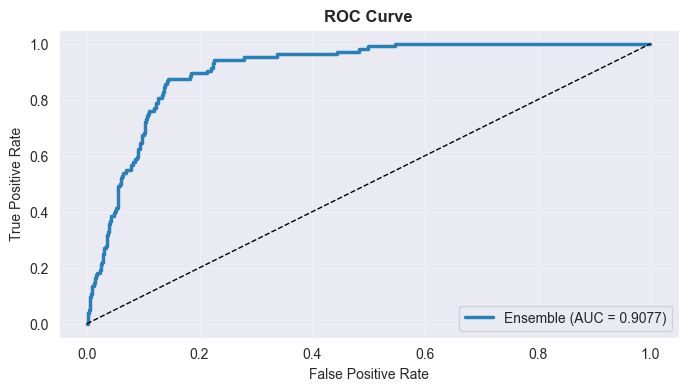

In [20]:
plt.figure(figsize=(8, 4))
# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, final_prob)
plt.plot(fpr, tpr, color='#2980b9', lw=2.5,
             label=f'Ensemble (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve", fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)





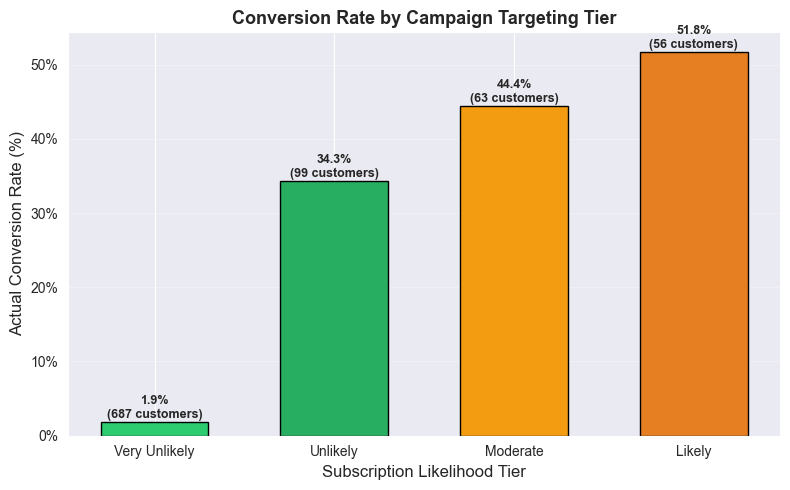

In [21]:
import matplotlib.ticker as mtick

tier_stats = final_df.groupby("Subscription_Likelihood", observed=True).agg(
    Total_Customers=("Actual", "count"),
    Actual_Subscribers=("Actual", "sum"),
    Conversion_Rate=("Actual", "mean")
).reset_index()

colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    tier_stats["Subscription_Likelihood"],
    tier_stats["Conversion_Rate"] * 100,
    color=colors, edgecolor='black', width=0.6
)

for bar, (_, row) in zip(bars, tier_stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row["Conversion_Rate"]*100:.1f}%\n({int(row["Total_Customers"])} customers)',
        ha='center', fontsize=9, fontweight='bold'
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Subscription Likelihood Tier', fontsize=12)
ax.set_ylabel('Actual Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate by Campaign Targeting Tier', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
import joblib

pt = joblib.load("Data/pt.pkl")   # load pt saved from DATA_PREPROCESSING.ipynb

joblib.dump({
    "lr_model":       lr_model,
    "xgb_calibrated": xgb_calibrated,
    "scaler":         scaler,
    "pt":             pt,
    "train_columns":  X.columns.tolist(),
    "best_w_lr":      best_w_lr,
    "best_w_xgb":     1-best_w_lr,
    "best_thresh":    best_thresh,
}, "model_artifacts_optimal.pkl")

print("Saved model_artifacts_optimal.pkl")

Saved model_artifacts_optimal.pkl
